In [ ]:
!pip install -r requirements.txt

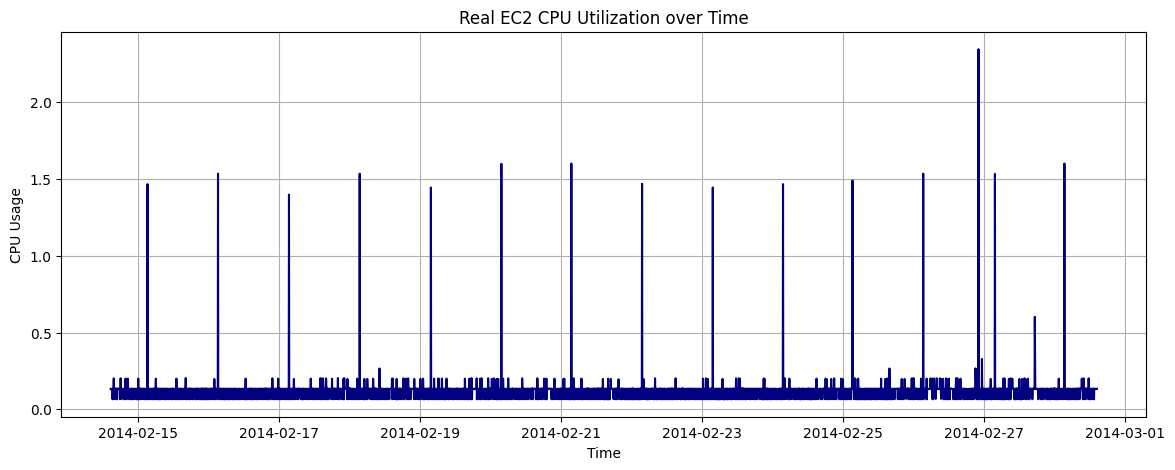

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the real AWS server data
df = pd.read_csv('ec2_cpu_utilization_24ae8d.csv')

# Convert the timestamp strings into manipulatable datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Plot the real server traffic
plt.figure(figsize=(14, 5))
plt.plot(df['timestamp'], df['value'], color='navy')
plt.title('Real EC2 CPU Utilization over Time')
plt.xlabel('Time')
plt.ylabel('CPU Usage')
plt.grid(True)
plt.show()

In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler 
import joblib

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

def load_real_metrics_data(csv_path="ec2_cpu_utilization_24ae8d.csv"):
    print(f"[Data] Loading real server metrics from {csv_path}...")
    df = pd.read_csv(csv_path) 
    
    # Extract ONLY the 'value' column as a 2D array for the scaler
    values = df['value'].values.reshape(-1, 1)
    
    # Neural networks prefer inputs between 0 and 1
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(values)
    joblib.dump(scaler, 'scaler.gz')
    return scaled_data

def build_sequences(data, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# --- 1. PREPARE THE DATA ---
raw_data = load_real_metrics_data()
WINDOW_SIZE = 10
X, y = build_sequences(raw_data, window_size=WINDOW_SIZE)

# Split into 80% training data and 20% testing data
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# --- 2. BUILD & TRAIN THE MODEL ---
print("[Deep Learning] Building Model Architecture...")

with tf.device('/device:GPU:0'):
    model = Sequential([
        Input(shape=(WINDOW_SIZE, 1)), # FIX: Explicit Input layer
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    print("[Deep Learning] Training LSTM Network on Real AWS Data...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=15,
        batch_size=32,
        verbose=1
    )
    
    # FIX: Using the modern .keras format
    model.save("server_lstm_model.keras") 
    print("[Success] Model trained on GPU and saved to 'server_lstm_model.keras'")

Num GPUs Available:  1
[Data] Loading real server metrics from ec2_cpu_utilization_24ae8d.csv...
[Deep Learning] Building Model Architecture...
[Deep Learning] Training LSTM Network on Real AWS Data...
Epoch 1/15
101/101 [==============================] - 4s 15ms/step - loss: 0.0015 - val_loss: 0.0029
Epoch 2/15
101/101 [==============================] - 1s 9ms/step - loss: 0.0015 - val_loss: 0.0029
Epoch 3/15
101/101 [==============================] - 1s 9ms/step - loss: 0.0015 - val_loss: 0.0030
Epoch 4/15
101/101 [==============================] - 1s 10ms/step - loss: 0.0015 - val_loss: 0.0030
Epoch 5/15
101/101 [==============================] - 1s 9ms/step - loss: 0.0014 - val_loss: 0.0029
Epoch 6/15
101/101 [==============================] - 1s 9ms/step - loss: 0.0015 - val_loss: 0.0029
Epoch 7/15
101/101 [==============================] - 1s 11ms/step - loss: 0.0015 - val_loss: 0.0029
Epoch 8/15
101/101 [==============================] - 1s 10ms/step - loss: 0.0014 - val_loss: 0